# Problem Definition

- Target variable: Bankrupt?
- Positive class: 1, meaning company went bankrupt
- Why the prediction task matters: the context is that we are helping a risk team identify companies that may go bankrupt.
- Whether the classes are balanced or imbalanced: Classes are imbalanced since there is data for only 220 bankrupt companies compared to 6,599 non-bankrupt companies. Approximately 3.2% of the data is the positive class.
- Your primary discrimination metric: PR-AUC
- How you will assess probability calibration: Looking for a low Brier score


# EDA

In [34]:
#Load libraries
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

In [35]:
#Load file as dataframe
df = pd.read_csv("data.csv")

In [36]:
#Display dataset shape
print('Dataset shape:',df.shape)

Dataset shape: (6819, 96)


In [37]:
#Target Distribution
bankrupt_counts = df["Bankrupt?"].value_counts().sort_index()
print("Bankrupt? distribution:")
print(bankrupt_counts)

Bankrupt? distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64


In [38]:
missing = df.isna().sum()
print("Missing Values:", missing.sum())
print("Missing Count by Column:\n", missing)

Missing Values: 0
Missing Count by Column:
 Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64


In [39]:
duplicates = df.duplicated().sum()
print("Duplicate row count:", duplicates)

Duplicate row count: 0


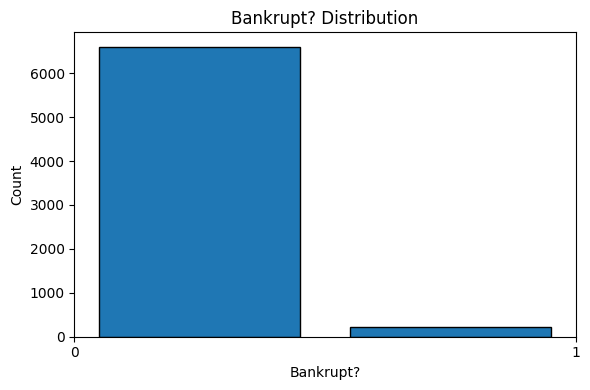

In [40]:
plt.figure(figsize=(6, 4))
df["Bankrupt?"].plot(kind="hist", bins=2, edgecolor="black", rwidth=0.8)
plt.title("Bankrupt? Distribution")
plt.xlabel("Bankrupt?")
plt.ylabel("Count")
plt.xticks([0, 1])
plt.tight_layout()
plt.show()

Observation: The classes are imbalanced, so I will use PR-AUC as a primary metric since it takes it into account focusing on true positives.

# 3. Train, Validation, Test Split 


| Split | Percent | Purpose |
| -------- | -------- | -------- |
| Train | 70% | Fit models |
| Validation | 15% | Compare models and choose threshold |
| Test | 15% | Final checks only |

# 4. Preprocessing

In [41]:
#Handle missing values for y
df = df.dropna(subset=['Bankrupt?'])

In [42]:
# Separate target from features and remove the target from X
target_col = 'Bankrupt?'
X = df.drop(columns=[target_col])
y = df[target_col]

In [43]:
#Identify Categorical Features
categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_categorical_cols = X.select_dtypes(include=['int']).columns.tolist()

#Print list of categorical columns if there are any
print('Categorical columns found:', len(categorical_cols))
print(categorical_cols)
print('Numerical categorical columns found:', len(num_categorical_cols))
print(num_categorical_cols)

Categorical columns found: 0
[]
Numerical categorical columns found: 2
[' Liability-Assets Flag', ' Net Income Flag']


In [44]:
#Check for leakage columns through correlation
correlation = df.corr()['Bankrupt?'].abs().sort_values(ascending=False)
correlation.head(6)

Bankrupt?                                                   1.000000
 Net Income to Total Assets                                 0.315457
 ROA(A) before interest and % after tax                     0.282941
 ROA(B) before interest and depreciation after tax          0.273051
 ROA(C) before interest and depreciation before interest    0.260807
 Net worth/Assets                                           0.250161
Name: Bankrupt?, dtype: float64

# Train, Validation, Test Split

In [45]:
#Split the data into train and temp set using 70/30 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

#Split the temp dataset into validation and test set using 50/50 split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Class imbalance in each set:')
print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)
print('y_test:', y_test.shape)

Class imbalance in each set:
X_train: (4773, 95)
X_val: (1023, 95)
X_test: (1023, 95)
y_train: (4773,)
y_val: (1023,)
y_test: (1023,)


In [46]:
#Handle missing values for X
impute = SimpleImputer(strategy='median')

X_train = impute.fit_transform(X_train)
X_val = impute.transform(X_val)
X_test = impute.transform(X_test)

# Feature Sets

In [47]:
# Create Feature Set A (all features) and Feature Set B (top 20 XGBoost features)

# Rebuild DataFrames so feature names are preserved after imputation
feature_names = X.columns.tolist()
X_train_df = pd.DataFrame(X_train, columns=feature_names, index=y_train.index)
X_val_df = pd.DataFrame(X_val, columns=feature_names, index=y_val.index)
X_test_df = pd.DataFrame(X_test, columns=feature_names, index=y_test.index)

# Feature Set A: all available features
X_train_a = X_train_df
X_val_a = X_val_df
X_test_a = X_test_df


# Feature Set B: top 20 features from an XGBoost feature importance model
dtrain = xgb.DMatrix(X_train_df, label=y_train)

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 6,
    "eta": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

feature_selector_model = xgb.train(params, dtrain, num_boost_round=100)

feature_importance = pd.DataFrame(
    {
        "Feature": list(feature_selector_model.get_score(importance_type="gain").keys()),
        "Importance": list(feature_selector_model.get_score(importance_type="gain").values())
    }
).sort_values(by="Importance", ascending=False)

feature_set_b = feature_importance.head(20)["Feature"].tolist()
X_train_b = X_train_df[feature_set_b]
X_val_b = X_val_df[feature_set_b]
X_test_b = X_test_df[feature_set_b]


# Experiments

In [48]:
# Log Experiment

results_table = pd.DataFrame(
    columns=[
        "exp_id",
        "model",
        "feature_set",
        "main_settings",
        "train_pr_auc",
        "val_pr_auc",
        "overfit_gap",
        "val_roc_auc",
        "val_brier",
        "threshold",
        "val_precision",
        "val_recall",
        "val_f2",
        "selected_finalist",
        "notes"
    ]
)

# Global experiment counter
exp_counter = 1

def run_experiment(model, X_train, y_train, X_val, y_val, model_name, feature_set, settings, results_table, threshold=0.5, notes=""):
    global exp_counter

    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        train_scores = model.predict_proba(X_train)[:, 1]
        val_scores = model.predict_proba(X_val)[:, 1]
    else:
        train_scores = model.predict(X_train).astype(float)
        val_scores = model.predict(X_val).astype(float)

    val_preds = (val_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, val_preds, labels=[0, 1]).ravel()

    val_precision = tp / (tp + fp) if (tp + fp) else 0.0
    val_recall = tp / (tp + fn) if (tp + fn) else 0.0
    beta_sq = 2 ** 2
    val_f2 = (
        (1 + beta_sq) * val_precision * val_recall / (beta_sq * val_precision + val_recall)
        if (val_precision + val_recall) else 0.0
    )

    train_pr_auc = average_precision_score(y_train, train_scores)
    val_pr_auc = average_precision_score(y_val, val_scores)
    overfit_gap = train_pr_auc - val_pr_auc
    val_roc_auc = roc_auc_score(y_val, val_scores)
    val_brier = brier_score_loss(y_val, val_scores)

    results_table.loc[len(results_table)] = {
        "exp_id": exp_counter,
        "model": model_name,
        "feature_set": feature_set,
        "main_settings": settings,
        "train_pr_auc": round(train_pr_auc, 4),
        "val_pr_auc": round(val_pr_auc, 4),
        "overfit_gap": round(overfit_gap, 4),
        "val_roc_auc": round(val_roc_auc, 4),
        "val_brier": round(val_brier, 4),
        "threshold": round(float(threshold), 2),
        "val_precision": round(val_precision, 4),
        "val_recall": round(val_recall, 4),
        "val_f2": round(val_f2, 4),
        "selected_finalist": "No",
        "notes": notes
    }

    exp_counter += 1
    return results_table

In [49]:
#Dummy baseline on Feature Set A
results_table = run_experiment(
    model=DummyClassifier(strategy="prior"),
    X_train=X_train_a,
    y_train=y_train,
    X_val=X_val_a,
    y_val=y_val,
    model_name="Dummy Classifier",
    feature_set="Feature Set A",
    settings="strategy=prior",
    results_table=results_table,
    threshold=0.5,
    notes="Reference benchmark for comparison."
)

In [50]:
# XGBoost baseline on Feature Set A
results_table = run_experiment(
    model=xgb.XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    X_train=X_train_a,
    y_train=y_train,
    X_val=X_val_a,
    y_val=y_val,
    model_name="XGBoost Baseline",
    feature_set="Feature Set A",
    settings="default XGBoost settings",
    results_table=results_table,
    threshold=0.5,
    notes="Baseline tree model on all features."
)

In [51]:
# XGBoost with imbalance handling on Feature Set A
results_table = run_experiment(
    model=xgb.XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=30,
        max_depth=3,
        n_estimators=50
    ),
    X_train=X_train_a,
    y_train=y_train,
    X_val=X_val_a,
    y_val=y_val,
    model_name="XGBoost Imbalance Handling",
    feature_set="Feature Set A",
    settings="scale_pos_weight=30, max_depth=3, n_estimators=250",
    results_table=results_table,
    threshold=0.5,
    notes="Class imbalance handled with scale_pos_weight=30 and a shallower model."
)

In [52]:
# XGBoost tuned with a small RandomizedSearchCV on Feature Set A
param_dist = {
        "n_estimators": [50, 100, 150, 250, 300],
        "max_depth": [2, 3, 4, 5, 6],
        "learning_rate": [0.03, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
    }

xgb_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    max_depth=2,
    subsample=0.06,
    reg_lambda=5
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_a, y_train)
best_random = random_search.best_estimator_
best_settings = ", ".join(
    [f"{key}={value}" for key, value in random_search.best_params_.items()]
)

results_table = run_experiment(
    model=best_random,
    X_train=X_train_a,
    y_train=y_train,
    X_val=X_val_a,
    y_val=y_val,
    model_name="XGBoost RandomizedSearchCV",
    feature_set="Feature Set A",
    settings=best_settings,
    results_table=results_table,
    threshold=0.5,
    notes="Best of 5 RandomizedSearchCV candidates scored by ROC-AUC."
)

model = random_search.best_estimator_


In [53]:
# XGBoost selected features on Feature Set B
results_table = run_experiment(
    model=xgb.XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        max_depth=1,
        n_estimators=200,
        learning_rate=0.1,
        subsample=0.8
    ),
    X_train=X_train_b,
    y_train=y_train,
    X_val=X_val_b,
    y_val=y_val,
    model_name="XGBoost Selected Features",
    feature_set="Feature Set B",
    settings="max_depth=1, n_estimators=200, learning_rate=0.1, subsample=0.8",
    results_table=results_table,
    threshold=0.5,
    notes="Relative baseline XGBoost using Feature Set B"
)

# Threshold Selection Strategy

Choose the threshold that gives the best validation F2 score.

In [54]:
val_proba_exp4 = model.predict_proba(X_val_a)[:, 1]
candidate_thresholds = np.arange(0.05, 1.00, 0.05)

threshold_results = []
for threshold in candidate_thresholds:
    val_pred = (val_proba_exp4 >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, val_pred, labels=[0, 1]).ravel()

    val_precision = tp / (tp + fp) if (tp + fp) else 0.0
    val_recall = tp / (tp + fn) if (tp + fn) else 0.0
    beta_sq = 2 ** 2
    val_f2 = (
        (1 + beta_sq) * val_precision * val_recall / (beta_sq * val_precision + val_recall)
        if (val_precision + val_recall) else 0.0
    )

    threshold_results.append(
        {
            "threshold": round(threshold, 2),
            "val_precision": round(val_precision, 4),
            "val_recall": round(val_recall, 4),
            "val_f2": round(val_f2, 4)
        }
    )

threshold_results = pd.DataFrame(threshold_results)
best_threshold_row = threshold_results.loc[threshold_results["val_f2"].idxmax()]
best_threshold_exp4 = float(best_threshold_row["threshold"])

results_table.loc[results_table["exp_id"] == 4, ["threshold", "val_precision", "val_recall", "val_f2"]] = [
    best_threshold_row["threshold"],
    best_threshold_row["val_precision"],
    best_threshold_row["val_recall"],
    best_threshold_row["val_f2"]
]

best_threshold_row.to_frame().T


,threshold,val_precision,val_recall,val_f2
1,0.1,0.3649,0.8182,0.6553


# Results Table

In [55]:
# Select best model based on validation PR-AUC
max = results_table['val_pr_auc'].max()
results_table.loc[results_table['val_pr_auc'] == max, 'selected_finalist'] = 'Yes'

results_table

,exp_id,model,feature_set,main_settings,train_pr_auc,val_pr_auc,overfit_gap,val_roc_auc,val_brier,threshold,val_precision,val_recall,val_f2,selected_finalist,notes
0,1,Dummy Classifier,Feature Set A,strategy=prior,0.0323,0.0323,0.0000,0.5000,0.0312,0.5,0.0000,0.0000,0.0000,No,Reference benchmark for comparison.
1,2,XGBoost Baseline,Feature Set A,default XGBoost settings,1.0000,0.4889,0.5111,0.9527,0.0238,0.5,0.6250,0.3030,0.3378,No,Baseline tree model on all features.
2,3,XGBoost Imbalance Handling,Feature Set A,"scale_pos_weight=30, max_depth=3, n_estimators...",0.9934,0.5025,0.4910,0.9605,0.0299,0.5,0.4423,0.6970,0.6250,No,Class imbalance handled with scale_pos_weight=...
3,4,XGBoost RandomizedSearchCV,Feature Set A,"subsample=1.0, n_estimators=250, max_depth=2, ...",0.7979,0.5249,0.2731,0.9643,0.0208,0.1,0.3649,0.8182,0.6553,Yes,Best of 5 RandomizedSearchCV candidates scored...
4,5,XGBoost Selected Features,Feature Set B,"max_depth=1, n_estimators=200, learning_rate=0...",0.5955,0.4614,0.1341,0.9558,0.0222,0.5,0.6667,0.2424,0.2778,No,Relative baseline XGBoost using Feature Set B


# Final Test Evaluation

In [56]:
# Evaluate on the Test set
y_test_proba = model.predict_proba(X_test_a)[:, 1]
y_test_pred = (y_test_proba >= best_threshold_exp4).astype(int)

Test set evaluation:
PR AUC: 0.4955343839288016
ROC AUC: 0.9465564738292012
Brier Score: 0.02280398793600754
Test Precision: 0.296875
Test Recall: 0.5757575757575758
Test F2 Score: 0.4846938775510205
Confusion Matrix:
 [[945  45]
 [ 14  19]]
Final Threshold: 0.1
Final Model Settings: subsample=1.0, n_estimators=250, max_depth=2, learning_rate=0.05, colsample_bytree=0.6


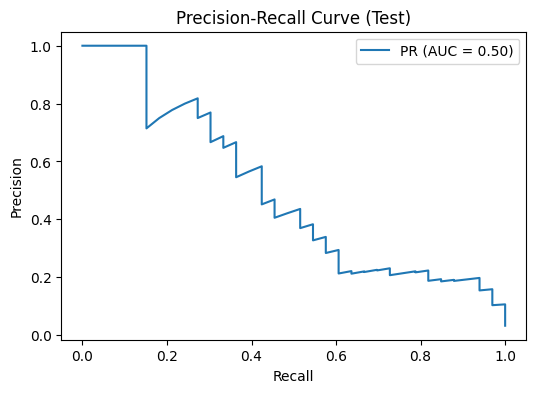

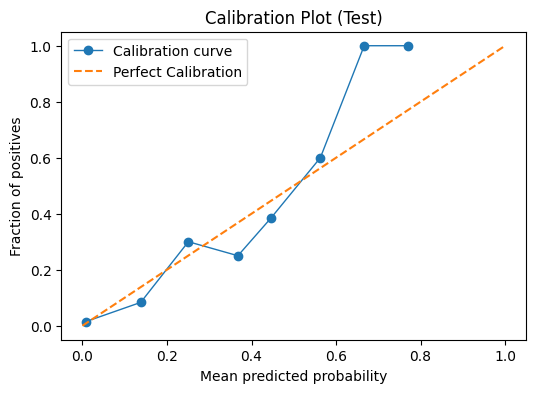

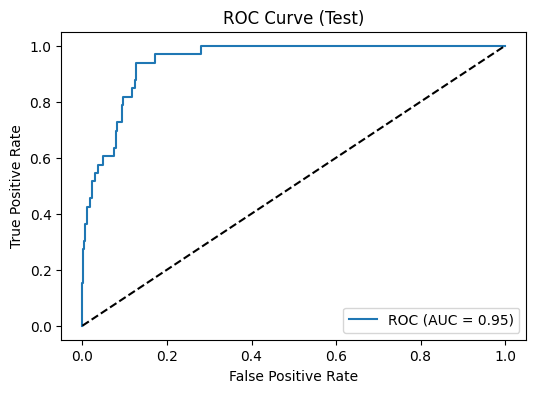

In [57]:
#Evaluate on Test Set
pr_auc_test = average_precision_score(y_test, y_test_proba)
roc_auc_test = roc_auc_score(y_test, y_test_proba)
brier_test = brier_score_loss(y_test, y_test_proba)
cm_test = confusion_matrix(y_test, y_test_pred)
tn_test, fp_test, fn_test, tp_test = cm_test.ravel()
test_precision = tp_test / (tp_test + fp_test) if (tp_test + fp_test) else 0.0
test_recall = tp_test / (tp_test + fn_test) if (tp_test + fn_test) else 0.0
beta_sq = 2 ** 2
test_f2 = (
    (1 + beta_sq) * test_precision * test_recall / (beta_sq * test_precision + test_recall)
    if (test_precision + test_recall) else 0.0
)

print("Test set evaluation:")
print("PR AUC:", pr_auc_test)
print("ROC AUC:", roc_auc_test)
print("Brier Score:", brier_test)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F2 Score:", test_f2)
print("Confusion Matrix:\n", cm_test)
print("Final Threshold:", threshold_results['threshold'].iloc[1])
print("Final Model Settings:", best_settings)

# Precision-Recall curve (Test)
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'PR (AUC = {pr_auc_test:.2f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Test)")
plt.legend()
plt.show()

# Calibration plot (Test)
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10)
plt.figure(figsize=(6, 4))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Calibration curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot (Test)")
plt.legend()
plt.show()

# ROC AUC plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()

# Calibration Check

Brier Score: 0.02280398793600754


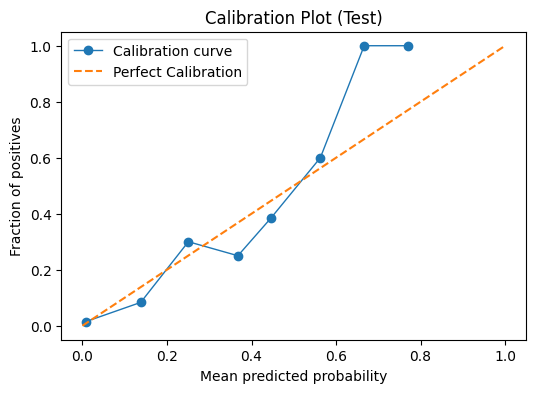

In [58]:
print("Brier Score:", brier_test)

# Calibration plot (Test)
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10)
plt.figure(figsize=(6, 4))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Calibration curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot (Test)")
plt.legend()
plt.show()

In [59]:
NUM_FEATS = 20

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.Importance[:NUM_FEATS], y=feature_importance.Feature[:NUM_FEATS])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top Feature Importances")
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x600 with 0 Axes>